### Extra-correctness, parse event by event
This is parsed in Notebook 3.

In [1]:
%reload_ext autoreload
%autoreload 2

In [10]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import starbars
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_figures.figure3d import find_theta_dynamics_animals
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (return_num_of_arms,
    return_meta_data, GLM_max_proportion, model2numbers, violin_plot)
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (
    GLM_correctness_local, GLM_correctness_remote,
    GLM_correctness1, GLM_arm_num_reward,
    GLM_correctness2, GLM_correctness3, GLM_correctness_by_animal, correct_future_2_arm_rep)

In [3]:
num_of_arms = {}
contain_home = {}
contain_long_theta = {}
time_spent = {}
rewards = {}
sd=6
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_count_{animal}_{sd}'
    file_path = output_folder + '.pkl'

    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    num_of_arms[animal] = data["num_of_arms"]
    contain_home[animal] = data["contain_home"]
    contain_long_theta[animal] = data["contain_long_theta"]
    time_spent[animal] = data["remote_time_spent"]
    rewards[animal] = data["rewards"]

### 1. Simple conditioning plot

In [11]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],
           color = color_by_rat[animal], alpha=0.6)
    if draw_text:
        ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table, alternative = "greater")
    p_value = res.pvalue
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

def draw_annotation(ijps,ax,height = 0.9):
    for ijp in ijps:
        x1, x2, p = ijp
        if p <= 0.001:
            label = "***"
        elif p <= 0.01:
            label = "**"
        elif p <= 0.05:
            label = "*"
        ax.text(np.mean([x1,x2]), height, label)

pvalue molly 0.20990804549785896
pvalue eliot 0.3482672472310637
pvalue julio 0.0065938257812294294
pvalue klein 0.39496406779519605
pvalue lewis 0.06866081106698942


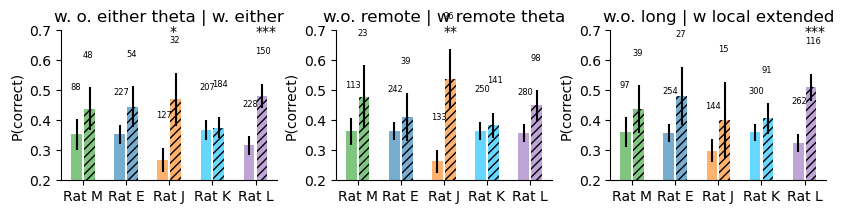

In [9]:
num_of_panels = 3
draw_text = True
fig, axes = plt.subplots(1, num_of_panels, figsize=(3 * num_of_panels, 2.8))#sharey = True)

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]#["molly","eliot","julio","lewis","klein"]#["molly","lewis","julio","klein"]

annotations = {i:[] for i in range(3)}

for animal in animals:

    remote_theta = (np.array(num_of_arms[animal]) - np.array(contain_long_theta[animal]).astype("int")) > 0

    (reward,
     long_theta, theta, theta_home) = (
        np.array(rewards[animal]),
        np.array(contain_long_theta[animal]),
         np.array(num_of_arms[animal]) > 0,np.array(contain_home[animal]))

    reward_theta = np.array(reward)[np.array(theta) > 0]
    reward_nontheta = np.array(reward)[~(np.array(theta) > 0)]
    reward_remote_theta = np.array(reward)[np.array(remote_theta) > 0]
    reward_nonremote_theta = np.array(reward)[~(np.array(remote_theta) > 0)]
    reward_long_theta = np.array(reward)[np.array(long_theta) > 0]
    reward_nonlong_theta = np.array(reward)[~(np.array(long_theta) > 0)]

    # axis 1: nontheta vs theta
    ax = axes[0]
    data1, data2 = reward_nontheta, reward_theta
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    if pvalue <= 0.05:
        annotations[0].append((0 + animal_ind, 0.3 + animal_ind, pvalue))
    
    # axis 2: nontheta vs theta
    ax = axes[1]
    data1, data2 = reward_nonremote_theta, reward_remote_theta
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    #_, pvalue = ranksums(data1, data2, "less")
    print("pvalue", animal, pvalue)
    if pvalue <= 0.05:
        annotations[1].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    # axis 3: nontheta vs long theta
    ax = axes[2]
    data1, data2 = reward_nonlong_theta, reward_long_theta
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    if pvalue <= 0.05:
        annotations[2].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    animal_ind += 1


for j in range(3):
    ax = axes[j]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
        
    ax.set_xticks(np.arange(len(animals)) + .15);
    ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
    ax.set_ylabel("P(correct)")

    if j == 0:
        title = "w. o. either theta | w. either"
    elif j == 1:
        title = "w.o. remote | w remote theta"
    elif j == 2:
        title = "w.o. long | w local extended"
    draw_annotation(annotations[j],ax,height = 0.68)
        
    ax.set_title(title)
    ax.set_ylim([0.2,0.7])

plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_draw_test{draw_text}_versionb.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

### condensed

In [6]:
def plot_one_axis2(data1, data2, data3, animal_ind, ax, animal, draw_annotation = False, draw_text = True):

    annotations = []
    dx = 0.25
    width = 0.2
    std = [sd_err(data1), sd_err(data2), sd_err(data3)]
    mean = [np.mean(data1), np.mean(data2), np.mean(data3)]
    ax.bar([0 + animal_ind], [mean[0]], yerr=[std[0]], width=width, 
           fill=False, edgecolor = color_by_rat[animal], error_kw = {"ecolor": [0.3, 0.3, 0.3]})

    ax.bar([dx + animal_ind], [mean[1]], yerr=[std[1]], width=width,
           hatch=[''],color = color_by_rat[animal], alpha=0.3, error_kw = {"ecolor": [0.3, 0.3, 0.3]})

    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table, alternative = "greater")
    p_value = res.pvalue
    if p_value < 0.05:
        print("p_value", p_value)
        annotations.append((animal_ind, animal_ind + dx, np.round(p_value, 4)))

    ax.bar([2*dx + animal_ind],[mean[2]], yerr=[std[2]], width=width,
           hatch=[''],color = color_by_rat[animal], alpha=0.8, error_kw = {"ecolor": [0.3, 0.3, 0.3]})

    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data3 == 0), np.sum(data3 == 1)]])
    res = fisher_exact(table, alternative = "greater")
    p_value = res.pvalue
    if p_value < 0.05:
        print("p_value", p_value)
        annotations.append((animal_ind, 2*dx + animal_ind, np.round(p_value, 4)))
        
    if draw_annotation:
        starbars.draw_annotation(annotations, ax = ax)
    return annotations#, p_value

p_value 0.00783504763983604
p_value 0.0004080491213117728
p_value 0.015252355908099072


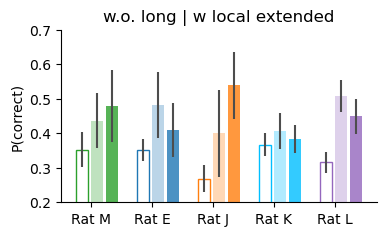

In [225]:
num_of_panels = 1
draw_text = False
fig, ax = plt.subplots(1, num_of_panels, figsize=(4.5,3))#sharey = True)

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]#["molly","eliot","julio","lewis","klein"]#["molly","lewis","julio","klein"]

annotations_all = []
for animal in animals:

    remote_theta = (np.array(num_of_arms[animal]) - np.array(contain_long_theta[animal]).astype("int")) > 0

    (reward,
     long_theta, theta, theta_home) = (
        np.array(rewards[animal]),
        np.array(contain_long_theta[animal]),
         np.array(num_of_arms[animal]) > 0,np.array(contain_home[animal]))

    reward_theta = np.array(reward)[np.array(theta) > 0]
    reward_nontheta = np.array(reward)[~(np.array(theta) > 0)]
    reward_remote_theta = np.array(reward)[np.array(remote_theta) > 0]
    reward_nonremote_theta = np.array(reward)[~(np.array(remote_theta) > 0)]
    reward_long_theta = np.array(reward)[np.array(long_theta) > 0]
    reward_nonlong_theta = np.array(reward)[~(np.array(long_theta) > 0)]


    data1 = reward_nontheta
    data2 = reward_long_theta
    data3 = reward_remote_theta
    annotations = plot_one_axis2(data1, data2, data3, animal_ind, ax, animal, draw_text = draw_text)
    #_, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    #if pvalue <= 0.05:
    #    annotations[2].append((0 + animal_ind, 0.3 + animal_ind, pvalue))
    
    annotations_all.extend(annotations)
    animal_ind += 1

if draw_text:
    starbars.draw_annotation(annotations_all, ax = ax)
else:
    ax.set_ylim([0.2,0.7])


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
        
ax.set_xticks(np.arange(len(animals)) + .15);
ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
ax.set_ylabel("P(correct)")


#title = "w. o. either theta | w. local ext | w. remote"
   
ax.set_title(title)


plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

if draw_text:
    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_draw_test{draw_text}_versionb_condensed_annotated.pdf"
else:
    
    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_draw_test{draw_text}_versionb_condensed.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

### 2. Various GLM models

#### (Figure A) local or remote

In [19]:
# local
model, logit_result = GLM_correctness_local(contain_home,
                                      num_of_arms,
                                      contain_long_theta, rewards)
print(logit_result.summary())
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result)
coef_est = np.exp(coef_est)
CI = np.exp(CI)

print(coef_est)
print(CI)
print(pvalues)

Optimization terminated successfully.
         Current function value: 0.652046
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1345
Model:                          Logit   Df Residuals:                     1339
Method:                           MLE   Df Model:                            5
Date:                Wed, 20 May 2026   Pseudo R-squ.:                0.008289
Time:                        14:41:27   Log-Likelihood:                -877.00
converged:                       True   LL-Null:                       -884.33
Covariance Type:            nonrobust   LLR p-value:                   0.01192
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.5562   5.82e+06  -9.55e-08      1.000   -1.14e+07    1.14e+07
Rat M            

In [20]:
# remote
model, logit_result = GLM_correctness_remote(contain_home,
                                      num_of_arms,
                                      contain_long_theta, rewards)
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result)
coef_est = np.exp(coef_est)
CI = np.exp(CI)

print(coef_est)
print(CI)
print(pvalues)

Optimization terminated successfully.
         Current function value: 0.652333
         Iterations 5
[1.49589489]
               0         1
remote  1.179027  1.897921
remote    0.000913
dtype: float64


##### (a) Any kind of theta content

In [226]:
model, logit_result = GLM_correctness1(contain_home,
                                      num_of_arms,
                                      contain_long_theta, rewards)

Optimization terminated successfully.
         Current function value: 0.652270
         Iterations 5


In [227]:
print(logit_result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1345
Model:                          Logit   Df Residuals:                     1339
Method:                           MLE   Df Model:                            5
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                0.007948
Time:                        08:31:08   Log-Likelihood:                -877.30
converged:                       True   LL-Null:                       -884.33
Covariance Type:            nonrobust   LLR p-value:                   0.01525
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.5849   3.21e+06  -1.82e-07      1.000   -6.29e+06    6.29e+06
Rat M                   -0.0418   3.21e+06   -1.3e-08      1.000   -6.29e+06    6.29e+06
Rat E       

[1.49969823]
                             0        1
rep. of alternatives  1.182409  1.90213
0.11000000000000001 0.03


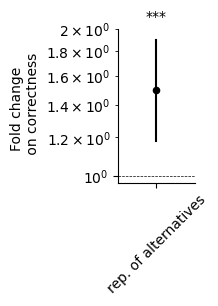

In [229]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,1,figsize=(1, 2))


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result)
coef_est = np.exp(coef_est)
CI = np.exp(CI)

print(coef_est)
print(CI)

axes.scatter(coef_names, coef_est, color = "k", s = 20)
for coef_name in coef_names:
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')


axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
#axes.set_title("logistic regression")
axes.set_ylabel("Fold change \n on correctness")
axes.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes.set_yscale('log') 
#axes.set_xlim([-0.5,2.5])
axes.set_ylim([0,2])
#axes.set_yticks([0.1, 1, 10])

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes, color = 'k')


# theta_point_est = coef_pd.loc["local extended"]
# theta_CI = CI.loc["local extended"]
# print(f"Fold change of the effect of long theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_GLM_model1_versionb.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

#### (b) remote arm, home, and local extended

In [208]:
model, logit_result = GLM_correctness2(contain_home,
                                      num_of_arms,
                                      contain_long_theta, rewards)

Optimization terminated successfully.
         Current function value: 0.651390
         Iterations 5


In [183]:
print(logit_result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1345
Model:                          Logit   Df Residuals:                     1337
Method:                           MLE   Df Model:                            7
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                0.009286
Time:                        14:14:41   Log-Likelihood:                -876.12
converged:                       True   LL-Null:                       -884.33
Covariance Type:            nonrobust   LLR p-value:                   0.02151
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.5754   4.65e+06  -1.24e-07      1.000   -9.12e+06    9.12e+06
Rat M               -0.0616   4.65e+06  -1.32e-08      1.000   -9.12e+06    9.12e+06
Rat E               -0.0240 

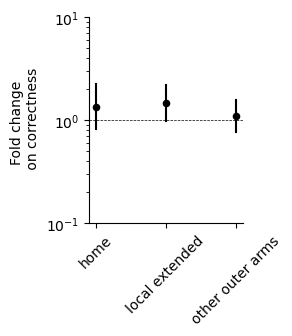

In [184]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,1,figsize=(3.5, 4))


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes.scatter(coef_names, coef_est, color = "k", s = 20)
for coef_name in coef_names:
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes, color = 'k')

axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
#axes.set_title("logistic regression")
axes.set_ylabel("Fold change \n on correctness")
axes.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes.set_yscale('log') 
#axes.set_xlim([-0.5,2.5])
axes.set_ylim([0,4.2])
axes.set_yticks([0.1, 1, 10])

# theta_point_est = coef_pd.loc["local extended"]
# theta_CI = CI.loc["local extended"]
# print(f"Fold change of the effect of long theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_GLM_model2_versionb.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

#### (c) home alone

In [185]:
model, logit_result = GLM_correctness3(contain_home,
                                      num_of_arms,
                                      contain_long_theta, rewards)

Optimization terminated successfully.
         Current function value: 0.654624
         Iterations 5


In [186]:
print(logit_result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1345
Model:                          Logit   Df Residuals:                     1337
Method:                           MLE   Df Model:                            7
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                0.004367
Time:                        14:14:42   Log-Likelihood:                -880.47
converged:                       True   LL-Null:                       -884.33
Covariance Type:            nonrobust   LLR p-value:                    0.3576
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.4946        nan        nan        nan         nan         nan
Rat M                 -0.0084        nan        nan        nan         nan         nan
Rat E               

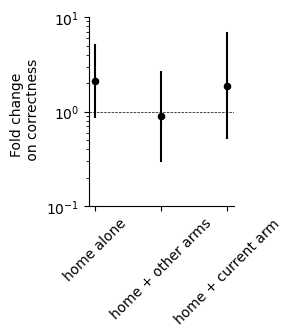

In [187]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,1,figsize=(3.5, 4))


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes.scatter(coef_names, coef_est, color = "k", s = 20)
for coef_name in coef_names:
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes, color = 'k')

axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
#axes.set_title("logistic regression")
axes.set_ylabel("Fold change \n on correctness")
axes.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes.set_yscale('log') 
#axes.set_xlim([-0.5,2.5])
axes.set_ylim([0,4.2])
axes.set_yticks([0.1, 1, 10])

# theta_point_est = coef_pd.loc["local extended"]
# theta_CI = CI.loc["local extended"]
# print(f"Fold change of the effect of long theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_GLM_model3_versionb.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

## Regression of number of arm and reward

In [209]:
model, logit_result = GLM_arm_num_reward(contain_home,
                                      num_of_arms,
                                      contain_long_theta, rewards)

Optimization terminated successfully.
         Current function value: 0.678103
         Iterations 4


In [210]:
print(logit_result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  466
Model:                          Logit   Df Residuals:                      460
Method:                           MLE   Df Model:                            5
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                0.007292
Time:                        08:25:04   Log-Likelihood:                -316.00
converged:                       True   LL-Null:                       -318.32
Covariance Type:            nonrobust   LLR p-value:                    0.4611
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.3070        nan        nan        nan         nan         nan
Rat M          -0.0509        nan        nan        nan         nan         nan
Rat E          -0.0798        nan        nan    

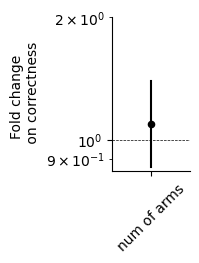

In [190]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,1,figsize=(1, 2))


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes.scatter(coef_names, coef_est, color = "k", s = 20)
for coef_name in coef_names:
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')


axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
#axes.set_title("logistic regression")
axes.set_ylabel("Fold change \n on correctness")
axes.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes.set_yscale('log') 
#axes.set_xlim([-0.5,2.5])
axes.set_ylim([0,2])
#axes.set_yticks([0.1, 1, 10])

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes, color = 'k')


# theta_point_est = coef_pd.loc["local extended"]
# theta_CI = CI.loc["local extended"]
# print(f"Fold change of the effect of long theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_GLM_model_num_versionb.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

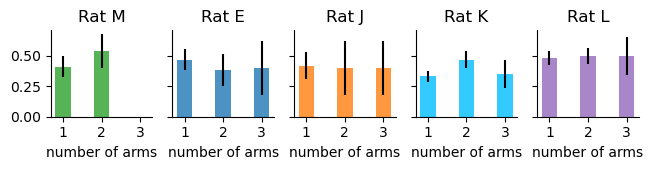

In [216]:
# excludes the current arm animal is in
animals = ["molly", "eliot", "julio", "klein", "lewis"]

x = [1,2,3]
fig, axes = plt.subplots(1,len(animals), figsize=(1.3*len(animals), 1.8), sharey = True)
animal_ind = 0
for animal in animals:
    long_theta = contain_long_theta[animal]
    
    num_of_arms_animal = np.array(num_of_arms[animal])
    contain_theta = num_of_arms_animal > 0
    num_of_arms_animal[long_theta] -= 1

    
    r = np.array(rewards[animal]).astype("int")
    rewards_by_num = [np.mean(r[np.logical_and(num_of_arms_animal == num, contain_theta)]) for num in x]
    rewards_sd_by_num = [sd_err(r[np.logical_and(num_of_arms_animal == num, contain_theta)]) for num in x]

    axes[animal_ind].bar(x,rewards_by_num, yerr=rewards_sd_by_num, width=0.4,color = color_by_rat[animal], alpha=0.8)


    axes[animal_ind].set_xticks(x)
    axes[animal_ind].set_xlabel("number of arms")
    axes[animal_ind].set_title(f"Rat {animal[0].upper()}")
    axes[animal_ind].spines['top'].set_visible(False)
    axes[animal_ind].spines['right'].set_visible(False)
    
    animal_ind += 1
plt.tight_layout()

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/"
plt.savefig(file_path + f'reward_vs_num.pdf',bbox_inches='tight')